**UPLOAD FILE**

In [1]:
from google.colab import *
uploaded = files.upload()

Saving Telco_churn.csv to Telco_churn.csv


**QUICK READ AND CHECK ON FILE**

In [2]:
import pandas as pd
import io
# Read file that is already uploaded
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Data successfully uploaded")

# quick check on file
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nUnique values in Churn column:")
print(df['Churn'].value_counts())

Data successfully uploaded
Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per 

**DATA CLEANING**

In [3]:
# Drop unimportant column (axis = 1). If row (axis = 0).
# Inplace = True ->reassign to df again. no new variable and customerID deleted immediately
df.drop('customerID', axis=1, inplace=True)

# coerce: Turn those problematic values (can't be converted to number) into NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert yes or no to 1 and 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaning done")
print(df[['TotalCharges', 'Churn']].head())



Cleaning done
   TotalCharges  Churn
0         29.85      0
1       1889.50      0
2        108.15      1
3       1840.75      0
4        151.65      1


**Separate Features (X) and Target (y)**

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

# Churn is 0 and 1. Use mean to find the proportion of data 1s
# :2f for formating to percentage
print(f"Churn Rate: {y.mean():.2%}")

X shape: (7043, 19)
y shape: (7043,)
Churn Rate: 26.54%


**PREPROCESSING PIPELINE**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Which column is number and which is object
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numeric features:", numeric_cols.to_list())
print("Categorical features:", categorical_cols.to_list())

# split data. test size = 20%, train size = 80 %
# random state = seed buat random 42
# stratify y = memastikan proporsi clas di train dan test tetap sama dengan dataset asli
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# standardscaler = scales your numbers so they have a mean of 0 and a standard deviation of 1.
# OneHotEncoder = It turns text (like "Jakarta", "Tangerang") into columns of 1s and 0s
# drop='first' untuk statistical trick to avoid the "Dummy Variable Trap."
# handle_unknown='ignore' = if your model sees a city in the test data that it never saw during training, it won't crash
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


# fit transform = preprocessor (like a StandardScaler or OneHotEncoder) "learns" the parameters from the data.
# Example: If you are scaling data, it calculates the mean and standard deviation of each column in X_train
# It applies those learned parameters to scale or encode the X_train data.
X_train_processed = preprocessor.fit_transform(X_train)

# Nggak perlu fit karena sudah belajar training jadi tinggal apply aja
X_test_processed = preprocessor.transform(X_test)

print("X train process shape", X_train_processed.shape)
print("Preprocessing berhasil")


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
X train process shape (5634, 30)
Preprocessing berhasil


**SMOTE**

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

**TRAIN DATA**

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# random forest create hundreds of individual Decision Trees.
# each tree looks at a random subset of the data and a random subset of the features.
# When you want a prediction, every tree "votes," and the majority winner becomes the final result.
# n_estimators=100 -> build 100 individual trees
# class_weight = 'balanced' -> to pay more attention to the minority class.
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# the model is looking for patterns: "When Feature A is high and Feature B is 'Jakarta', the result is usually 'Yes'."
rf.fit(X_train_resampled, y_train_resampled)

# gives you final answers
# The model looks at its internal "committee" of 100 trees.
# If 51 trees vote for "Yes" and 49 vote for "No," this command simply returns "Yes".
y_pred = rf.predict(X_test_processed)


# gives you confidence level
# Instead of just giving the winner, it tells you the percentage of trees that voted for the positive class (Class 1)
# 50an itu artinya not confident
# predict_proba returns two columns: [Probability of 0, Probability of 1].
# By adding [:, 1], you are telling Python: "Give me all rows, but only the second column (Probability of 1)."
y_prob = rf.predict_proba(X_test_processed)[:, 1]

y_pred_final = (y_prob >= 0.45).astype(int)

# Evaluasi
print("Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


# The Classification Report
# This table breaks down performance for both 'No Churn' and 'Churn' using three key lenses:
# Precision: "When the model says someone will Churn, how often is it actually right?" (Focuses on avoiding False Alarms).
# Recall (Sensitivity): "Out of all the people who actually Churned, how many did the model manage to catch?" (Focuses on not missing anyone).
# F1-Score: The harmonic mean of Precision and Recall. Since you used class_weight='balanced', this is the score you should watch most closely—it tells you if you've found a good middle ground.

# 2. ROC-AUC Score (y_prob)
# This is a single number between 0 and 1 that measures the model’s ability to distinguish between classes.
# 0.5: Your model is no better than a coin flip (random guessing).
# 0.7 – 0.8: Solid, acceptable performance.
# 0.9+: Excellent (but check for "data leakage"—it might be too good to be true!).

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.81      0.83      1035
       Churn       0.54      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409


ROC-AUC Score: 0.824

Confusion Matrix:
[[842 193]
 [143 231]]


**FEATURE ANALYSIS**

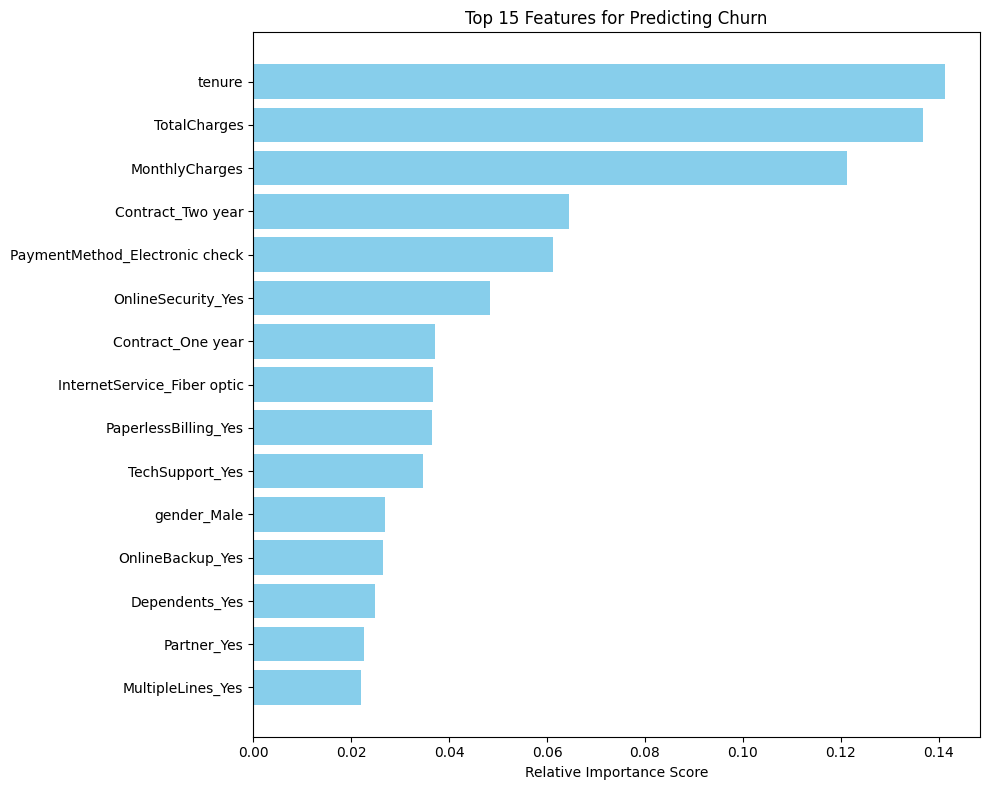

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = list(numeric_cols) + list(cat_features)

importances = rf.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 8))
plt.title('Top 15 Features for Predicting Churn')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

**VISUALIZATION**

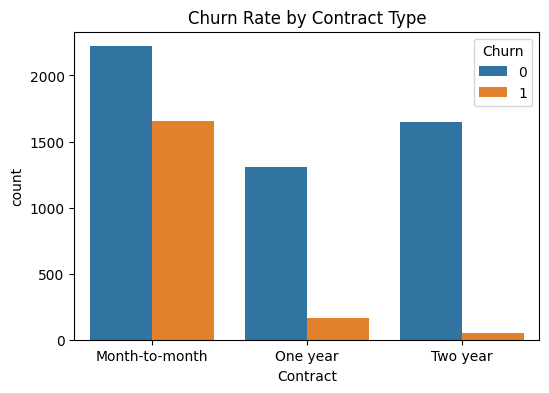

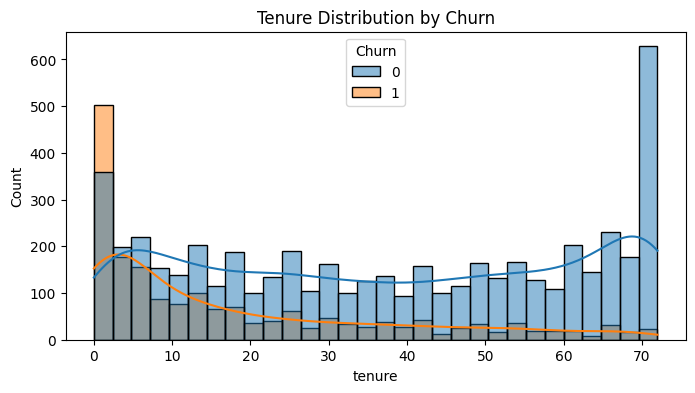

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn by contract type
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn Rate by Contract Type')
plt.show()

# Tenure distribution for churned vs not
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()